In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.collections import LineCollection

In [2]:
def make_shape(a = 2, b = 3, c = 3, d = 1, N = 100):

    t = np.linspace(0, 100, N)
    fig, ax = plt.subplots(figsize=(12, 8))

    # Point P(t)
    x1 = -2.2 * np.cos(2 * a * np.pi * t / 100)
    y1 =  0.6 * np.sin(2 * b * np.pi * t / 100) ** 3

    x2 =  0.5 * np.sin(2 * c * np.pi * t / 100)
    y2 =  1.1 * np.cos(2 * d * np.pi * t / 100)

    # Each row describes one line:
    # [(x1,y1), (x2,y2)]
    segments = np.stack(
        [
            np.column_stack((x1, y1)),
            np.column_stack((x2, y2))
        ],
        axis=1
    )


    collection = LineCollection(
        segments,
        linewidths=0.25, 
        colors = 'blue'
    )

    ax.add_collection(collection)

    ax.autoscale()
    
    ax.set_aspect("equal")
    ax.axis("off")


    plt.show()
    print(str(a)+ " " + str(b)+ " " + str(c)+ " " + str(d))
    # fig.savefig(
    #     "fish.png",
    #     dpi=300,
    #     bbox_inches="tight"
    # )

    # plt.close(fig)

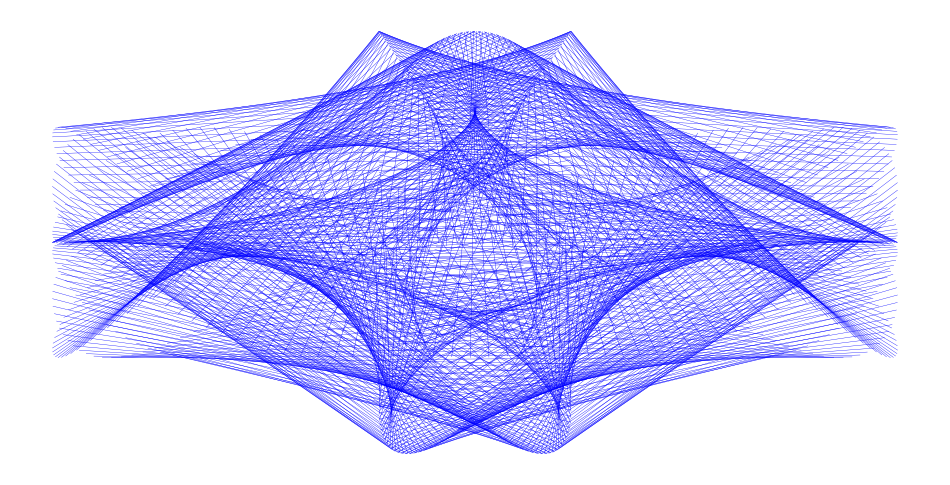

7 9 10 8


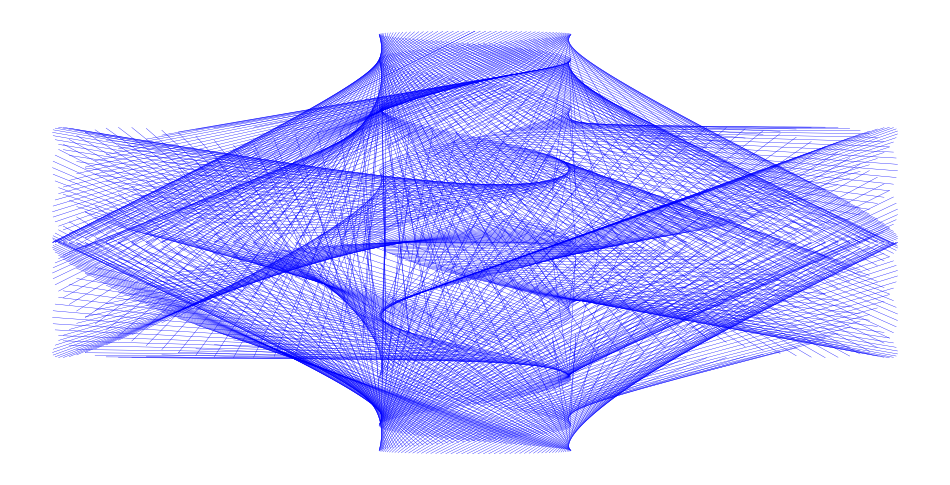

9 8 9 1


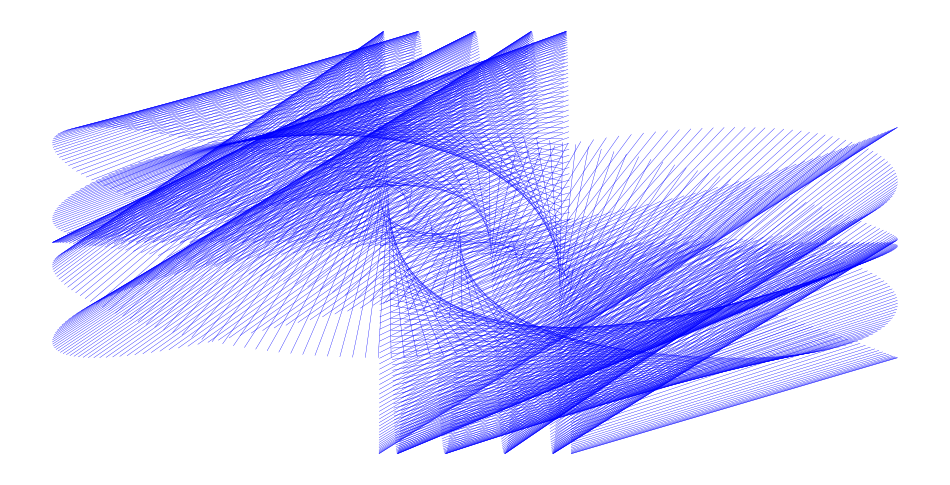

10 7 1 10


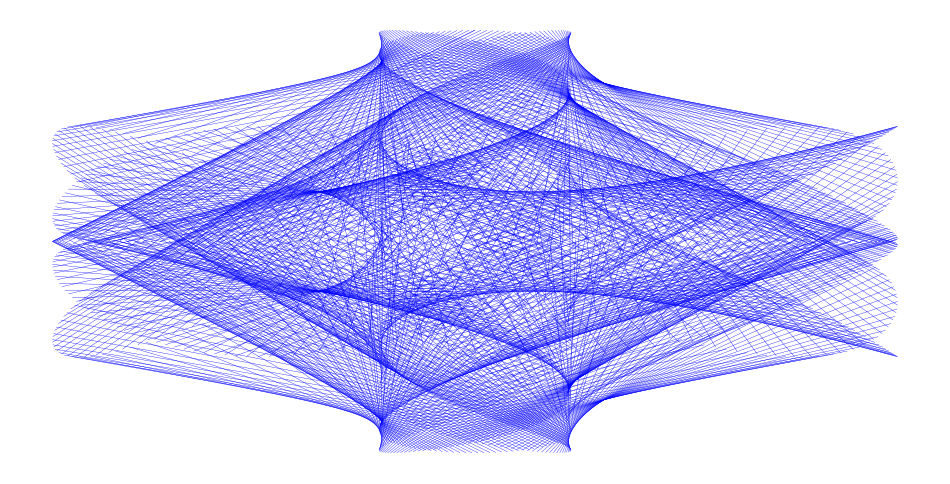

10 9 10 3


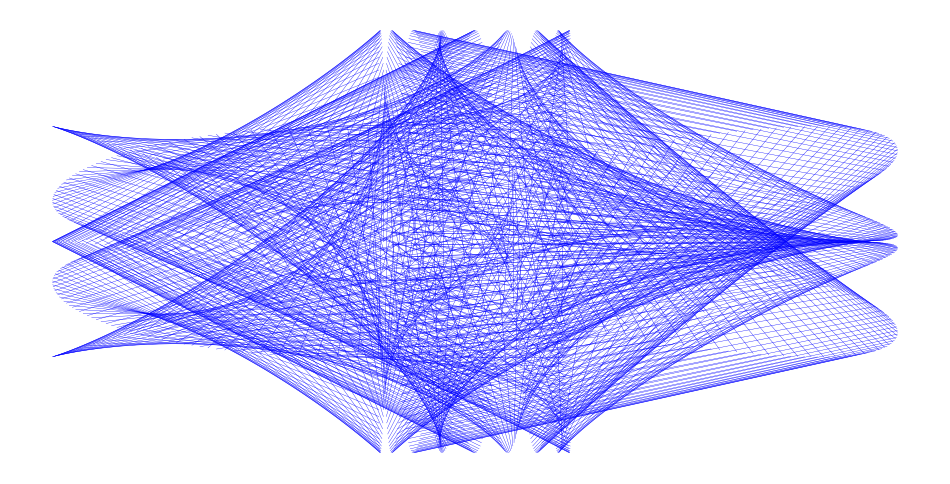

8 5 2 9


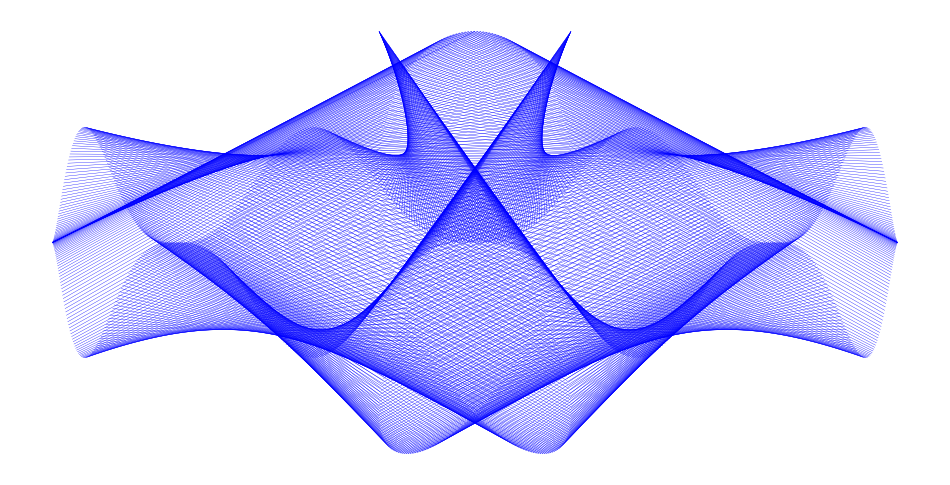

1 4 5 4


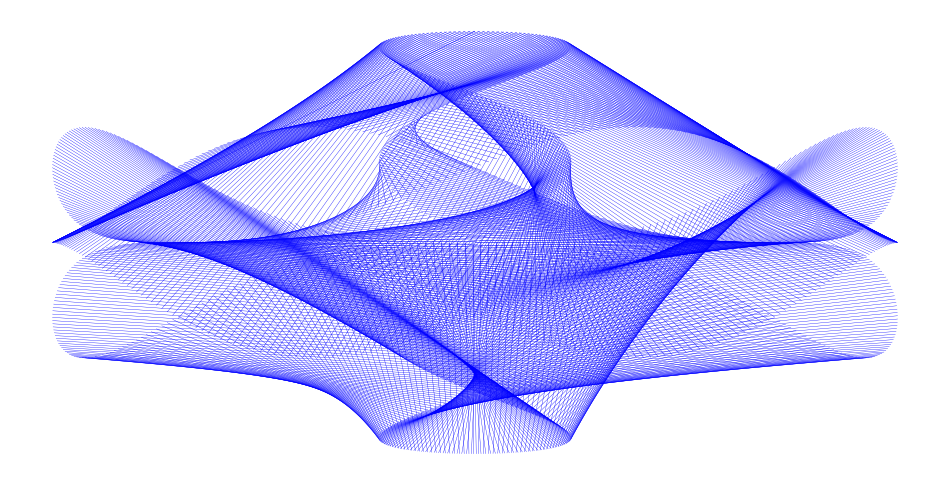

3 4 8 2


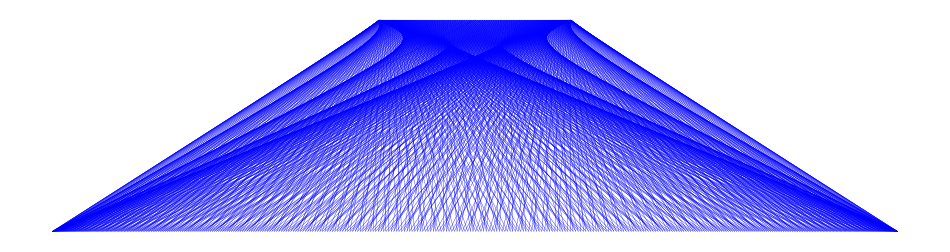

5 0 3 0


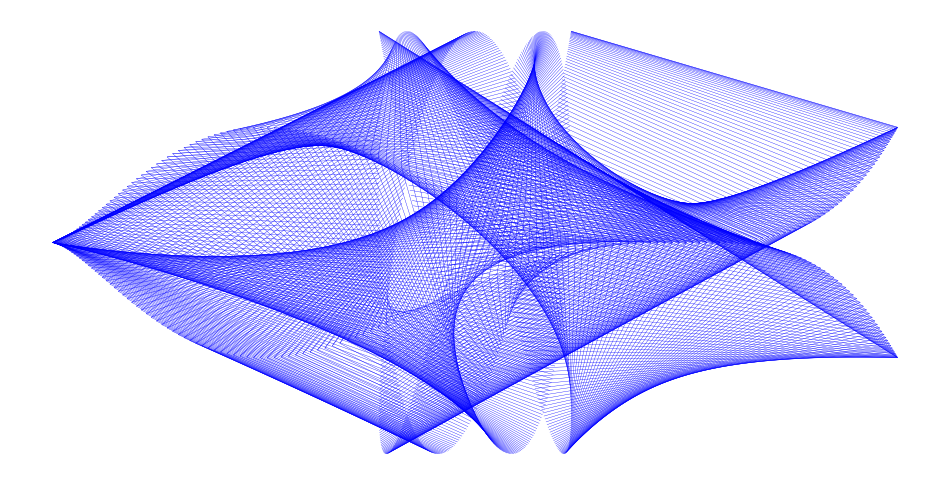

6 9 5 8


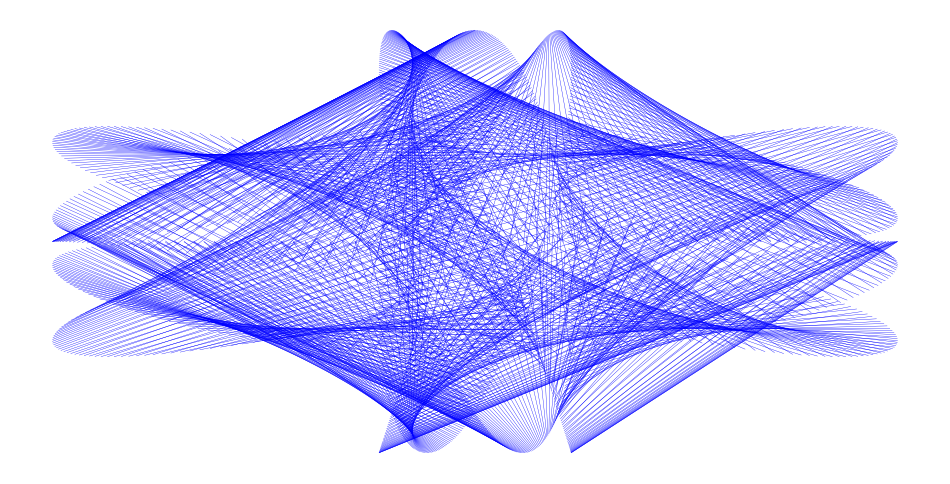

10 6 5 6


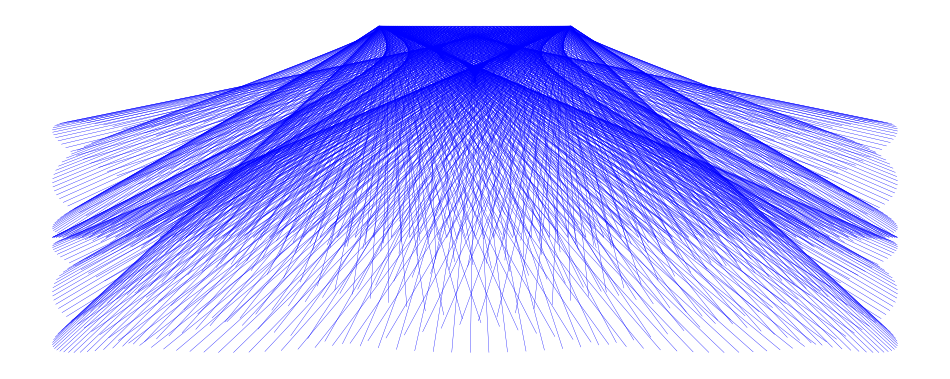

7 5 6 0


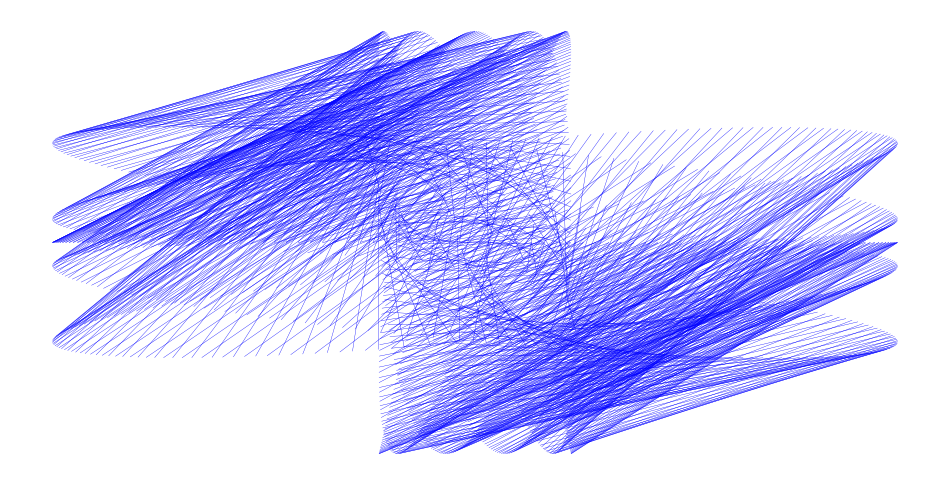

10 4 7 10


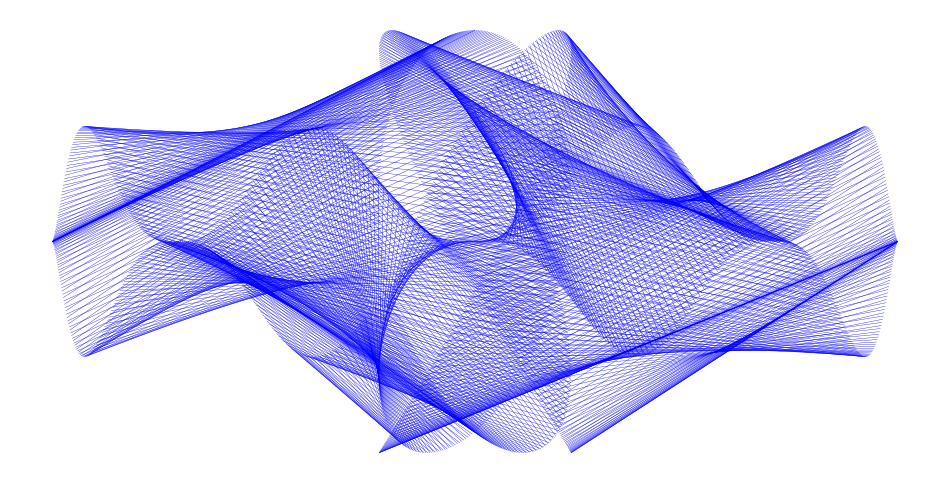

2 8 7 6


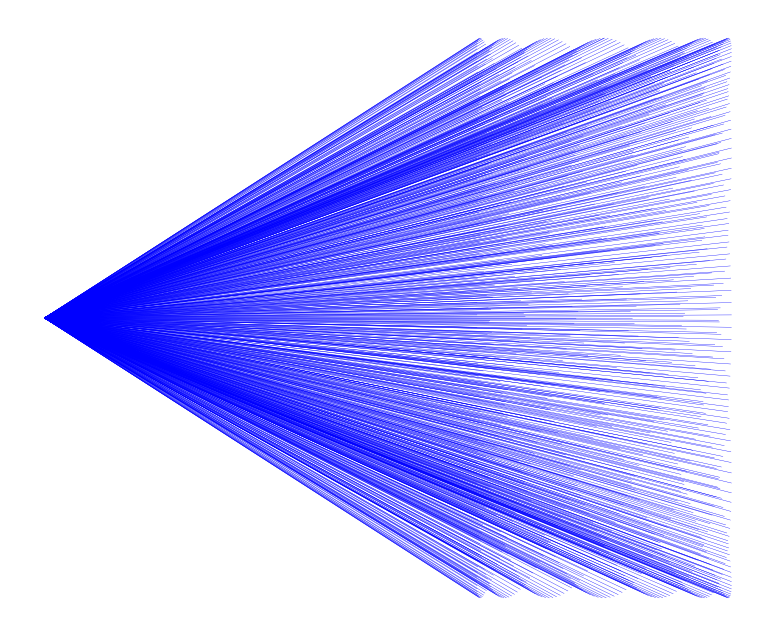

0 0 5 7


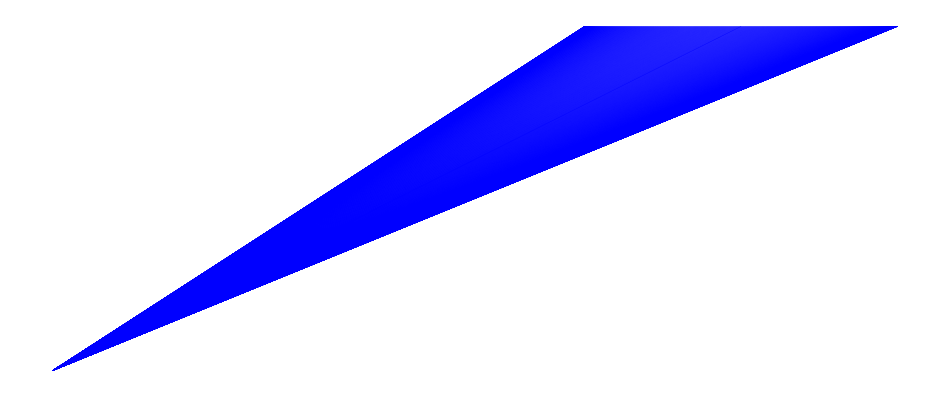

0 0 5 0


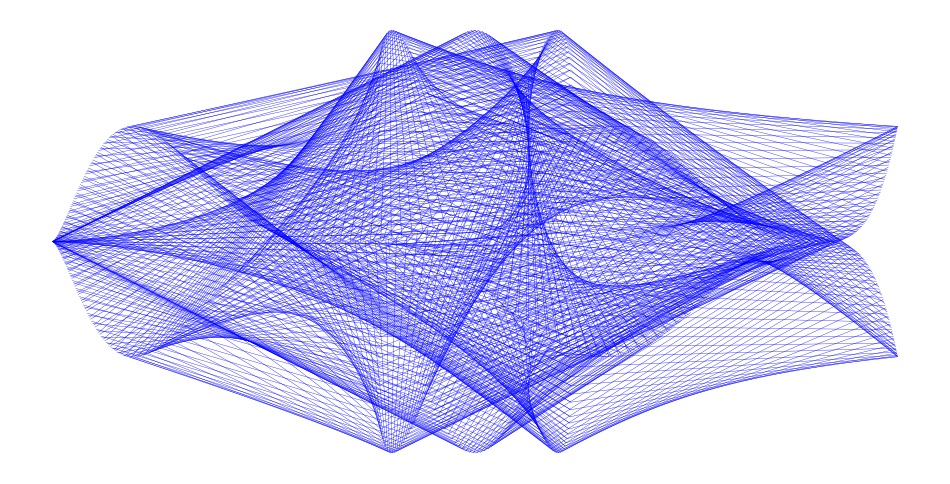

4 10 6 9


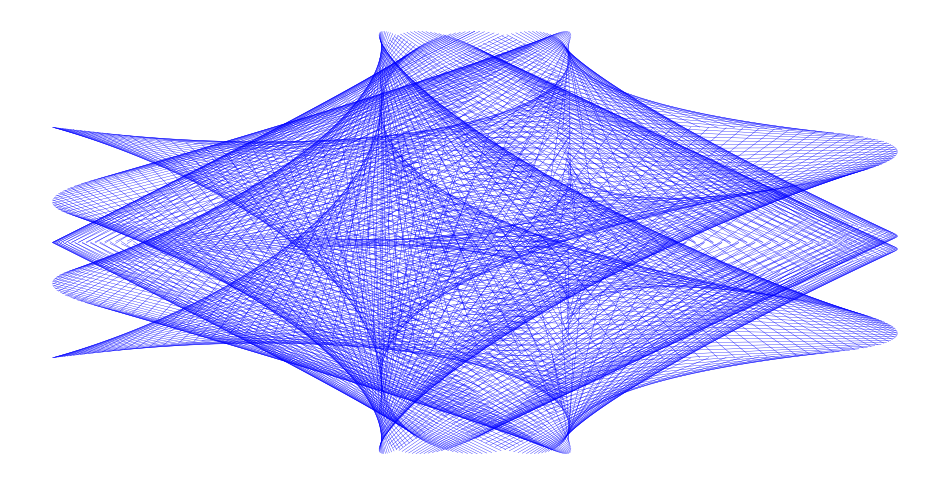

8 3 8 5


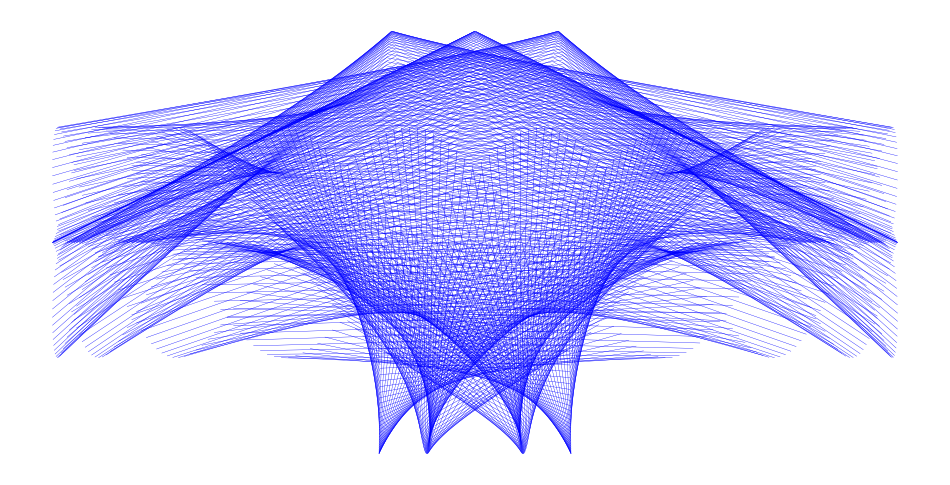

3 10 1 6


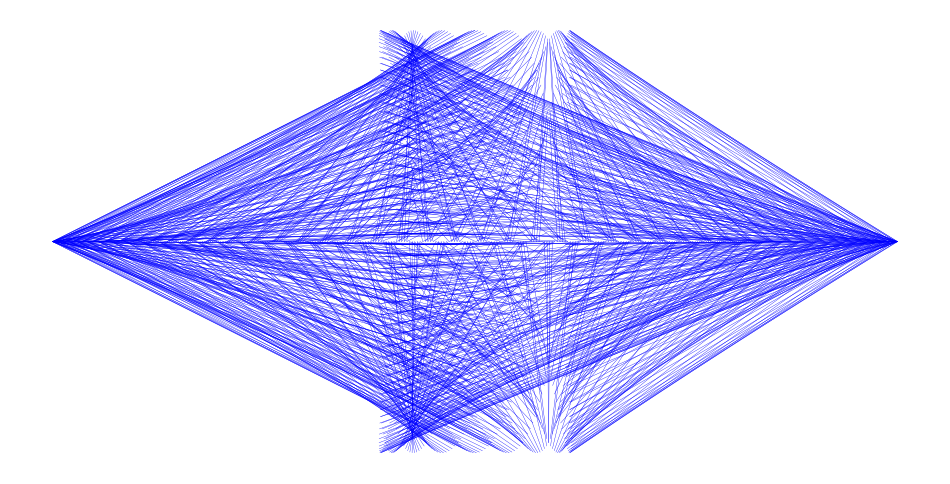

10 0 5 9


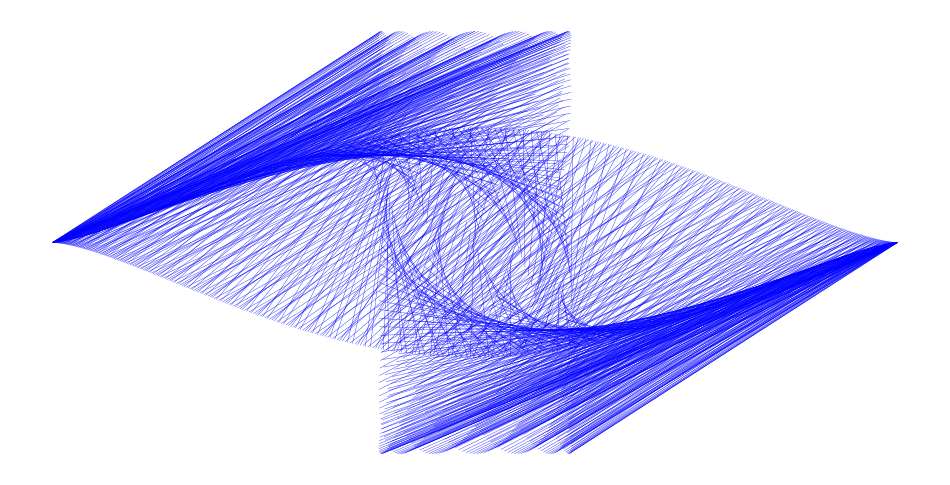

7 7 6 7


In [3]:
# Trying to find interesting shapes
import random
for i in range(20):
    a = random.randint(0, 10)
    b = random.randint(0, 10)
    c = random.randint(0, 10)
    d = random.randint(0, 10)

    make_shape(a, b, c, d, 1000)

## Trying to expand on the galaxy drawing

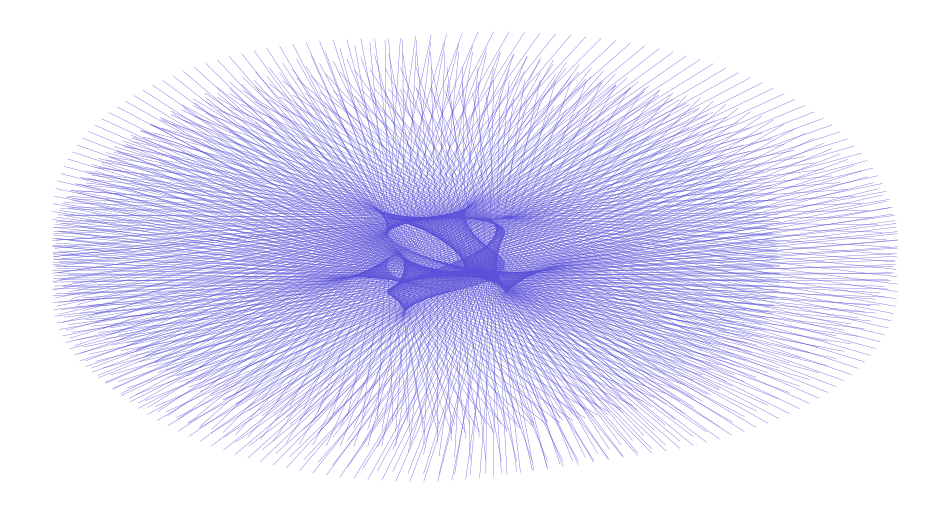

6 6 7 0


In [148]:
def make_galaxy(
    a=6,
    b=6,
    c=7,
    d=0,
    N=1000,
    graph=True,
    r=91,
    g=80,
    bl=217
):

    t = np.linspace(0, 100, N)

    if graph:
        fig, ax = plt.subplots(figsize=(12, 8))

    # Point P(t)
    x1 = (
        -2 * np.cos(2 * a * np.pi * t / 100)
        + 0.3 * np.sin(6 * np.pi * t / 100)
    )

    y1 = (
        1 * np.sin(2 * b * np.pi * t / 100)
        + 0.15 * np.sin(10 * np.pi * t / 100)
    )

    # Point Q(t)
    x2 = -0.3 * np.sin(2 * c * np.pi * t / 100)

    y2 = (
        1.0 * np.sin(2 * d * np.pi * t / 100)
        + 0.2 * np.cos(8 * np.pi * t / 100)
    )

    segments = np.stack(
        [
            np.column_stack((x1, y1)),
            np.column_stack((x2, y2))
        ],
        axis=1
    )

    # Convert 0–255 RGB to 0–1 RGB
    color = (
        r / 255,
        g / 255,
        bl / 255
    )

    collection = LineCollection(
        segments,
        linewidths=0.25,
        colors=[color]
    )

    if graph:
        ax.add_collection(collection)
        ax.autoscale()
        ax.set_aspect("equal")
        ax.axis("off")
        plt.show()

    print(a, b, c, d)

    if not graph:
        return collection

make_galaxy()

6 6 7 0
6.1 6.2 7.7 0


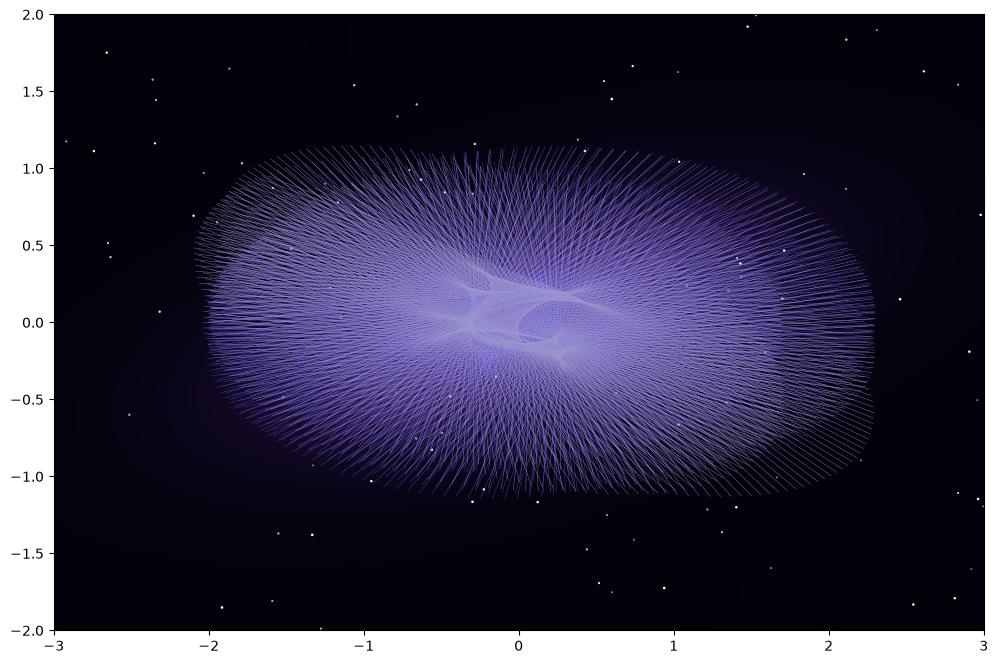

In [196]:
fig, ax = plt.subplots(figsize=(12, 8))

x_bg = np.linspace(-3, 3, 2000)
y_bg = np.linspace(-2, 2, 2000)

X, Y = np.meshgrid(x_bg, y_bg)

# Rotate galaxy background
angle = np.radians(15)

X_rot = X * np.cos(angle) + Y * np.sin(angle)
Y_rot = -X * np.sin(angle) + Y * np.cos(angle)

# Elliptical distance from center
radius = np.sqrt(
    (X_rot / 1.8)**2
    + (Y_rot / 0.7)**2
)

# Central structures
core = np.exp(-2.0 * radius**2)
halo = np.exp(-0.8 * radius**2)

# Subtle background texture
waves = (
    0.015 * np.cos(2 * X + 3 * Y)
    + 0.010 * np.cos(7 * X - 4 * Y)
    + 0.006 * np.sin(13 * X + 8 * Y)
)

# Dark purple-blue galaxy background
R = (
    0.012
    + 0.28 * core
    + 0.07 * halo
    + 0.015 * waves
)

G = (
    0.008
    + 0.15 * core
    + 0.025 * halo
    + 0.010 * waves
)

B = (
    0.040
    + 0.25 * core
    + 0.17 * halo
    + 0.025 * waves
)

background = np.dstack([
    np.clip(R, 0, 1),
    np.clip(G, 0, 1),
    np.clip(B, 0, 1)
])

# Adding stars
for i in range(100):
    x = random.uniform(-3, 3)
    y = random.uniform(-2, 2)
    radius = random.uniform(0.001, 0.004)

    circle = Circle(
        (x, y),
        radius=radius,
        facecolor="none",
        edgecolor="white"
    )

    ax.add_patch(circle)



ax.imshow(
    background,
    extent=[-3, 3, -2, 2],
    origin="lower",
    aspect="auto"
)

collection = make_galaxy(6, 6, 7, 0, 900, False)
ax.add_collection(collection)
collection = make_galaxy(6.1, 6.2, 7.7, 0, 1000, False, 156, 150, 207)
ax.add_collection(collection)
# collection = make_galaxy(6, 5, 7.7, 0, 1000, False, 49, 118, 140)
# ax.add_collection(collection)